# Exploring i.i.d. mutation effects

The effects of mutation on the growth rate (fitness) of offspring are independently and identically distributed at $L=2^n$ loci.

In [1]:
%matplotlib notebook
%run ../Code/bs.py

We start by defining the various Malthusian factors for 501 evenly spaced points over the intervals of birth/growth factors. In general, for $n$ points, there are $2n - 1$ discrete mutation effects.

In [2]:
factors = Factors(501)
len(factors.effects) == 2 * len(factors.growth) - 1

True

## Gaussian distribution of mutation effects

Now we define a discretized $\text{Normal}(0,\, 0.05)$ distribution over mutation effects.

<IPython.core.display.Javascript object>


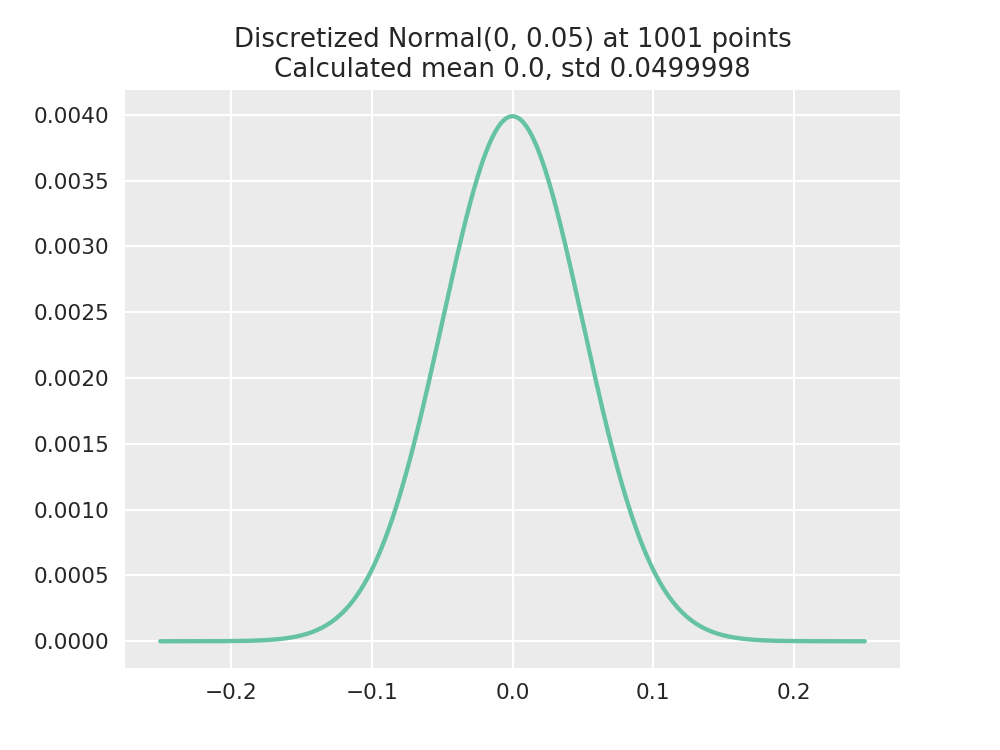

In [3]:
gauss = EffectsDistribution(factors, stats.norm(0, 0.05))
mean, variance = gauss.mean_and_variance()
fig, ax = plt.subplots()
title = 'Discretized Normal(0, 0.05) at {0} points\n'.format(len(gauss))
subtitle = 'Calculated mean {0:.6}, std {1:.6}'.format(mean, variance**0.5)
ax.set_title(title + subtitle)
gauss.line(ax);

### Test: Calculating the $L$-fold convolution of a Gaussian

We can obtain the $L$-fold convolution of an `EffectsDistribution` instance by calling its `iid_effects` method with the number of mutations per offspring set to $L = 2^n$ and the log-number of loci set to $n.$ The variance of the result is $L$ times the *actual* variance of the discrete distribution. However, the actual variance is not necessarily close to the variance of the continuous distribution in terms of which the discrete distribution is defined.

In the following test, we define the initial distribution in terms of $\text{Normal}(0, 0.05/\sqrt{L}),$ and compare the result of the $L$-fold convolution to $\text{Normal}(0, 0.05).$ For large $L,$ we must slice the interval of mutation effects finely to keep the actual standard deviation of the discretized distribution close to the specified value $0.05 / \sqrt{L}.$

<IPython.core.display.Javascript object>


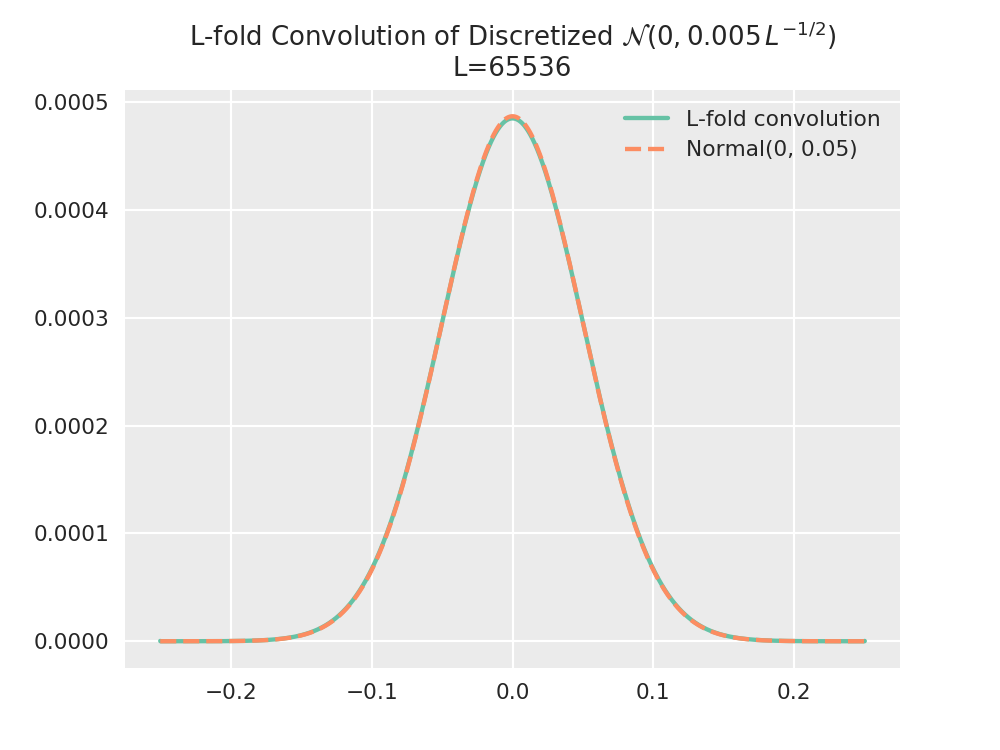

In [15]:
n = 16
L = 2**n
f = Factors(2**12+1)
target = EffectsDistribution(f, stats.norm(0, 0.05))
effects = EffectsDistribution(f, stats.norm(0, 0.05/np.sqrt(L)))
effects.iid_effects(number_of_mutations=L, log_number_of_loci=n)
fig, ax = plt.subplots()
title = 'L-fold Convolution of Discretized $\mathcal{N}(0, 0.005 \, L^{-1/2})$\n'
subtitle = 'L={0}'.format(L)
ax.set_title(title+subtitle)
ax.plot(f.effects, effects, label='L-fold convolution')
ax.plot(f.effects, target, label='Normal(0, 0.05)', ls='--')
ax.legend();

The following function plots&hellip;???. We immediately check to see that it reproduces the plot above when the standard deviation is 0.005, the number of mutations per organism is 1, and the number of loci is 1.

<IPython.core.display.Javascript object>


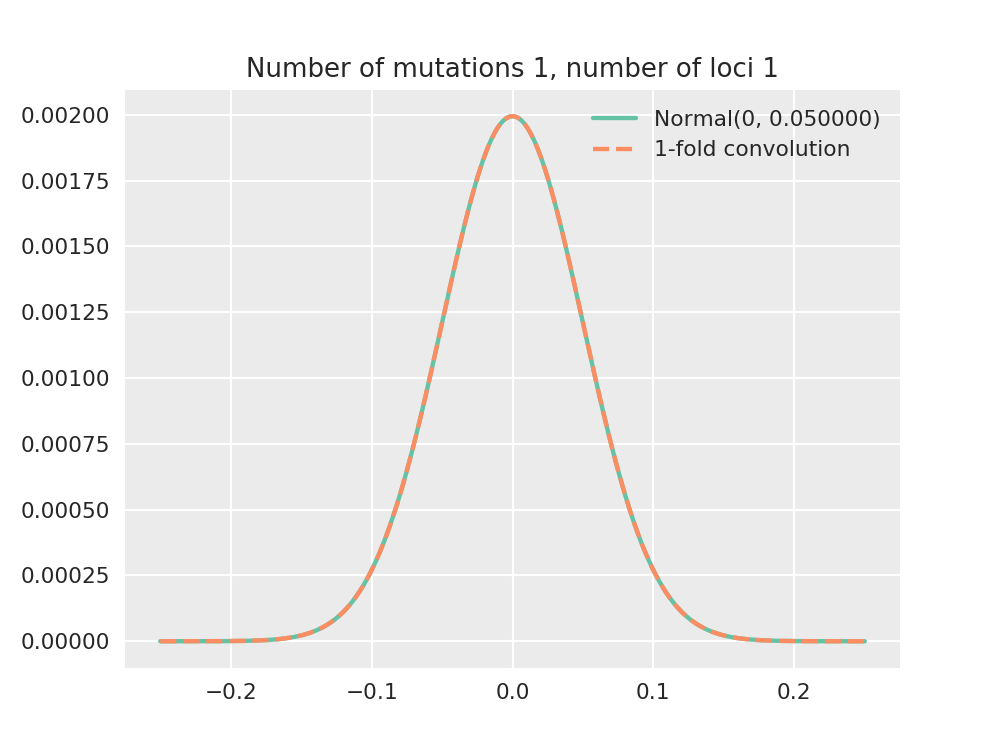

In [75]:
def plot(std, number_of_mutations, log_number_of_loci, linestyle='-'):
    fig = plt.figure()
    axes = fig.gca()
    effects = EffectsDistribution(factors, stats.norm(0, std))
    effects.line(axes, label='Normal(0, {0:f})'.format(std))
    effects.iid_effects(number_of_mutations, log_number_of_loci, truncate_self_convolution=False)
    line = effects.line(axes, label='{0}-fold convolution'.format(number_of_mutations))
    line.set_linestyle(linestyle)
    axes.legend(loc='best')
    axes.set_title('Number of mutations {0}, number of loci {1}'.format(number_of_mutations,
                                                                        2 ** log_number_of_loci))
    return effects, fig

plot(0.05, 1, 0, '--');

There are severe edge effects in the 4-fold convolution of a zero-mean, normal distribution when the results are limited to the interval $[-5\sigma,\, 5\sigma].$

<IPython.core.display.Javascript object>


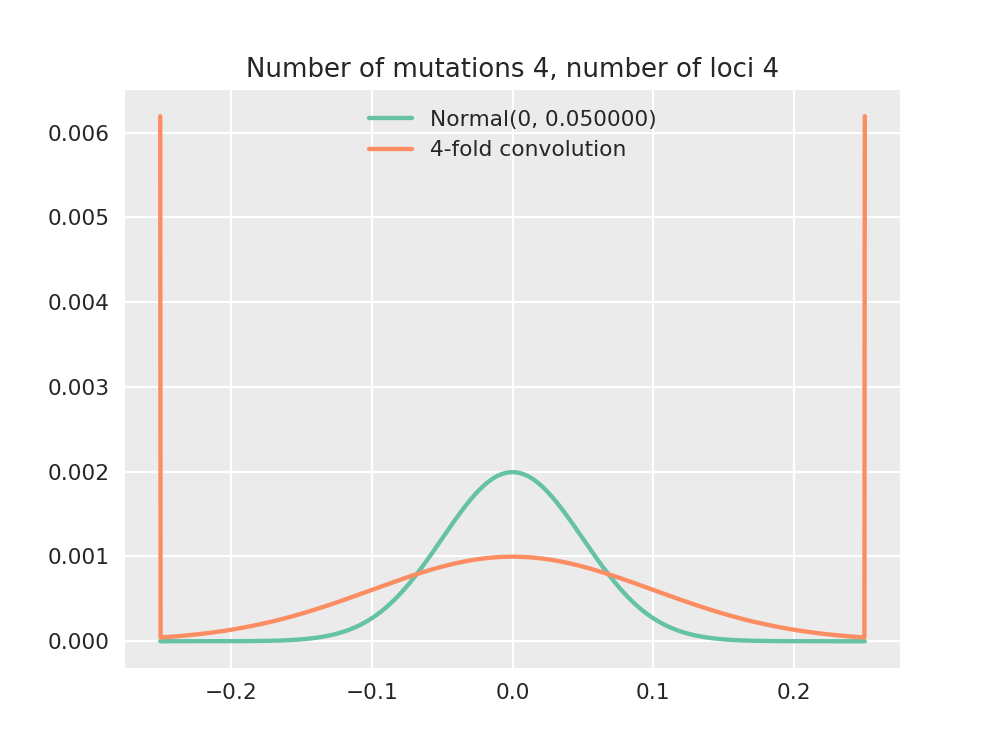

In [49]:
plot(0.05, 2**2, 2);

For the sake of testing, we instead treat $\text{Normal}(0,\, 0.05)$ as the desired *result* of the convolution. The variance of the result of the $L$-fold convolution is $L$ times the variance of the initial distribution. Thus we begin with a zero-mean normal distribution with standard deviation of $0.05 / \sqrt{L}.$

<IPython.core.display.Javascript object>


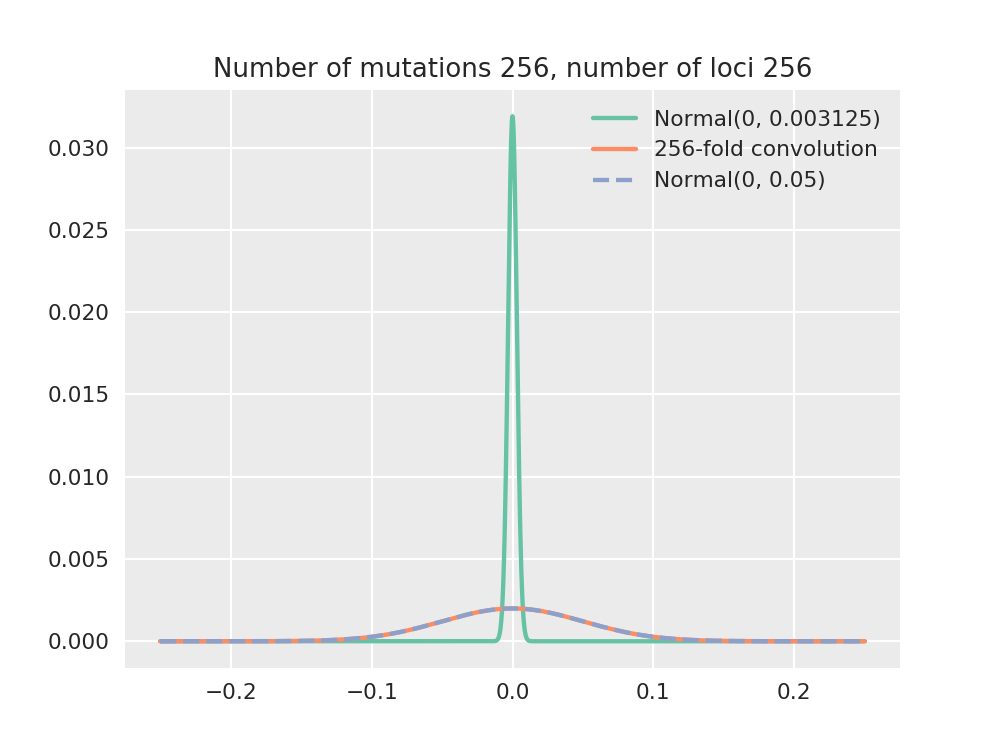

In [74]:
n=8
L = 2 ** n
plot(0.05/np.sqrt(L), L, n);
plt.plot(factors.effects, gauss, label='Normal(0, 0.05)', ls='--')
plt.legend(loc='best');

### Mutation effects

Now we consider $L = 2^n$ loci with 1 mutation per offspring. The standard deviation of the initial Gaussian distribution is equal to $0.02,$ as in Section 5.3 of the BS article. The expected number of mutations at any given site is $\mu = 1 / L.$ Thus, to obtain the distribution of probability over mutation effects at a site, we scale  the probabilities in the initial distribution by $\mu,$ and then add $1 - 1/L$ to the probability that mutation at the site has zero effect on the growth rate (fitness) of the offspring.

**TO DO**

## Symmetrized Gamma distribution of mutation effects

### Lumped effects

In [ ]:
asym = GammaEffects(percent_beneficial=0.001)  # BS Sect 5.4
sym = GammaEffects(percent_beneficial=None)

Verify that the beneficial tail of the reweighted distribution has been scaled to 0.001.

In [ ]:
mid = len(asym) // 2
beneficial = asym[mid+1:]
non_beneficial = asym[:mid+1]
s='beneficial sum {0:f} for {1} elements, non-beneficial sum {2:f} for {3} elements'
s.format(np.sum(beneficial), len(beneficial), np.sum(non_beneficial), len(non_beneficial))

Verify that the mean and variance of the (normalized) upper tail of the symmetrized Gamma distribution are close to the values $\alpha/\beta$ and $\alpha/\beta^2,$ respectively.

In [ ]:
mid = len(sym) // 2
x = sym.domain[mid:]
p = np.array(sym[mid:])
p[0] /= 2
p /= np.sum(p)
mean, variance = mean_and_variance(x, p)
s='mean, variance: {0:e}, {1:e} (expected: {2:e}, {3:e})'
s.format(mean, variance, sym.alpha/sym.beta, sym.alpha/sym.beta**2)

It is clear from the following plot why the observed mean and variance are not particularly close to the theoretically predicted values. The probability mass is concentrated on just a few discrete values. There is no reason to think that the discrete distribution would approximate the continuous distribution closely.

In [ ]:
fig = plt.figure()
axes = fig.gca()
shift = (sym.domain[1] - sym.domain[0]) / 8
plt.title('Symmetrized Gamma Before and After Reweighting')
sym.vlines(axes, -shift, label='Before').set_color(sns.xkcd_palette(['amber']))
asym.vlines(axes, shift, label='After').set_color(sns.xkcd_palette(['windows blue']))
plt.legend(loc='best')
plt.xlim(-0.01, 0.01);

Note that there are zoom and pan controls on the figure.

### Independent, identically distributed, additive mutation effects at loci

In [ ]:
log_L = 14
iid = GammaEffects(percent_beneficial=0.001, number_of_mutations=1, log_number_of_loci=log_L)
fig = plt.figure()
axes = fig.gca()
shift = (asym.domain[1] - asym.domain[0]) / 8
axes.set_title('Gamma Mutation Effects\n$L={0}$, $\mu=1/L$'.format(2**log_L))
axes.set_xlabel('Difference in Fitness of Offspring and Parent')
axes.set_ylabel('Probability')
asym.vlines(axes, -shift, label='Before').set_color(sns.xkcd_palette(['windows blue']))
iid.vlines(axes, shift, label='After').set_color(sns.xkcd_palette(['amber']))
plt.legend(loc='best')
plt.xlim(-0.01, 0.01);

**The ratio of the probability of deleterious mutation to the probability of beneficial mutation is somewhat greater with additive iid effects than with lumped effects.**

The probability of no mutation effect on growth rate is excluded from the following calculations.

In [ ]:
n = len(asym) // 2
lumped_ratio = np.sum(asym[:n]) / np.sum(asym[n+1:])
iid_ratio = np.sum(iid[:n]) / np.sum(iid[n+1:])
'Deleterious-to-beneficial ratio: lumped {0:f}, iid {1:f}'.format(lumped_ratio, iid_ratio)

## Animation
Now we animate four evolutionary processes that differ [**outdated description**] in the distribution of probability over mutation effects on the growth rates of offspring. The distributions are those of the preceding figure.

In [ ]:
n_years = 1600
init = GaussianRates(asym.n_rates)
pops = [Population(init, asym, label='One effect'),
        Population(init, iid, label='IID effects'),
        BS_Population(init, asym, label='One effect (BS)', threshold_norm=None,),
        BS_Population(init, iid, label='IID effects (BS)', threshold_norm=None),
        BS_Population(init, asym, label='One effect (BS)', threshold_norm=np.max),
        BS_Population(init, iid, label='IID effects (BS)', threshold_norm=np.max)]
processes = np.empty(len(pops), dtype=object)
processes[:] = [Evolution(p, n_years=n_years) for p in pops]
s = "\nGamma Mutation Effects, BS "
bs_infinite = CompareProcesses(processes[[0, 1, 2, 3]], subtitle=s+"Infinite")
bs_finite = CompareProcesses(processes[[0, 1, 4, 5]], subtitle=s+"Finite")

The time required to generate the following animation is proportional to the `stride` setting, which determines how many years the animator steps ahead in each frame. For a JS/HTML animation, the storage is also proportional to the stride. HTML5 comes with excellent compression, but requires that the FFmpeg package be installed on the server.

When the stride is set to None, a figure is generated instead of an animation. Figures, unlike animations, are displayed when a notebook is first loaded.

In [ ]:
plt.rcParams['animation.html'] = 'jshtml' # 'html5' requires FFmpeg
#with sns.color_palette():
#sns.set_palette("Paired")
sns.set_palette(sns.color_palette("Set2", 4))
bs_infinite.animate(stride=None)

Repeat without thresholding in the BS population.

In [ ]:
bs_finite.animate(stride=None)

## Some BS-Like Plots

In [ ]:
bs_infinite.mean_variance_plots()